<div style="background:linear-gradient(135deg,#4c0519 0%,#9f1239 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 181 &middot; Capstone 21 &middot; Experiment Design</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Designing an A/B Test Properly</div>
  <div style="font-size:15px;color:#fecdd3;max-width:820px;line-height:1.6">On day 4 the new checkout was winning by 15 percent. It has no effect at all. This notebook runs the test the way the plan said to run it, and then measures how often the day-4 answer happens by chance.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
RS, DK, LT, MUT, GD = "#9f1239", "#4c0519", "#fb7185", "#94a3b8", "#047857"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-designing-an-ab-test.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("assignments")
plan  = load("ExperimentPlan")
truth = load("truth")
TRUE_LIFT = float(truth.loc[truth.quantity.str.contains("true relative"), "value"].iloc[0])
print("rows in the assignment log:", f"{len(raw):,}")
raw.head()

rows in the assignment log: 80,236


,user_id,assign_day,arm,device,channel,returning,pre_revenue_30d,pre_orders_30d,converted,revenue
0,U612873,3,treatment,Desktop,Direct,0,6.43,0,0,0.0
1,U643537,8,treatment,Mobile,Email,1,10.64,2,0,0.0
2,U641972,8,treatment,Desktop,Direct,0,4.60,0,0,0.0
3,U637913,7,control,Desktop,Direct,0,18.46,1,0,0.0
4,U627300,5,treatment,Desktop,Direct,0,0.00,0,0,0.0


## Step 1 &middot; The plan, written before the traffic

Everything below was fixed on day 0. That is the point of reading it first: the sample size, the stopping rule and the exclusions are all decisions that become impossible to make honestly once you have seen a result.

In [2]:
for line in plan.experiment_plan.fillna(""):
    print(line)

PRE-REGISTERED ON DAY 0. Nothing below was decided after seeing data.

P1 HYPOTHESIS: the redesigned checkout increases the visitor-to-order conversion rate.
P2 PRIMARY METRIC: conversion rate = orders / assigned visitors. ONE primary metric.
P3 UNIT: the visitor. Randomization, analysis and inference are all at the visitor level.
P4 MDE: a 10% RELATIVE lift, 4.00% -> 4.40%. Below this the redesign does not pay back its
   build cost, so a smaller true effect is not a result we would act on.
P5 POWER: 80% at alpha = 0.05, two-sided. Two-sided because a drop must also be detectable.
P6 SAMPLE SIZE: 39,472 visitors per arm, 78,944 total. At about 5,700 visitors a day this
   is 14 days. The test runs for 14 whole days and stops there.
P7 STOPPING RULE: ONE analysis, at the planned end. If the team wants to look earlier, the
   sequential boundary in P8 applies instead, and it is fixed now rather than chosen later.
P8 SEQUENTIAL OPTION: if monitored daily, a single fixed boundary calibrat

**Read P4 and P7 together.** P4 says a lift below 10 percent is not worth acting on, which is a business judgment, not a statistical one. P7 says there will be **one** analysis, at the planned end. Those two lines are what make the rest of this notebook an experiment rather than a search.

## Step 2 &middot; How big, and how long

The sample size follows from four numbers, all of which are chosen before collection: the baseline rate, the smallest effect worth detecting, the power, and the significance level. Nothing about the data enters.

In [3]:
p1, p2 = 0.040, 0.044                    # baseline, and baseline + the 10% relative MDE
alpha, power = 0.05, 0.80
z_a, z_b = stats.norm.ppf(1 - alpha/2), stats.norm.ppf(power)

n_arm = (z_a + z_b)**2 * (p1*(1-p1) + p2*(1-p2)) / (p2 - p1)**2
print(f"baseline            {p1:.1%}")
print(f"MDE                 +10% relative  ->  {p2:.1%}   (a {(p2-p1)*100:.2f} point absolute move)")
print(f"power {power:.0%}, alpha {alpha}, two-sided")
print(f"\nrequired n per arm   {n_arm:,.0f}")
print(f"required n total     {2*n_arm:,.0f}")
print(f"at ~5,700 visitors/day, that is {2*n_arm/5700:.1f} days -> the plan says 14")

baseline            4.0%
MDE                 +10% relative  ->  4.4%   (a 0.40 point absolute move)
power 80%, alpha 0.05, two-sided

required n per arm   39,472
required n total     78,944
at ~5,700 visitors/day, that is 13.8 days -> the plan says 14


**The MDE is the expensive decision, and it is not a statistical one.** Sample size scales with the *inverse square* of the effect you want to catch, so halving the MDE quadruples the traffic. The table below is the conversation to have with the business before a line of code is written.

In [4]:
rows = []
for rel in [0.20, 0.15, 0.10, 0.07, 0.05, 0.03]:
    pp = p1 * (1 + rel)
    n  = (z_a + z_b)**2 * (p1*(1-p1) + pp*(1-pp)) / (pp - p1)**2
    rows.append({"relative MDE": f"{rel:.0%}", "detects": f"{p1:.2%} -> {pp:.2%}",
                 "n per arm": f"{n:,.0f}", "days at 5,700/day": f"{2*n/5700:,.0f}"})
print(pd.DataFrame(rows).to_string(index=False))

relative MDE        detects n per arm days at 5,700/day
         20% 4.00% -> 4.80%    10,313                 4
         15% 4.00% -> 4.60%    17,940                 6
         10% 4.00% -> 4.40%    39,472                14
          7% 4.00% -> 4.28%    79,458                28
          5% 4.00% -> 4.20%   154,301                54
          3% 4.00% -> 4.12%   424,617               149


**Chasing a 3 percent lift would take 149 days.** By then the site, the season and the audience have all changed, so the thing being measured is no longer the thing that was launched. A test that cannot finish inside a stable period is not a cheaper test, it is an unanswerable one.

## Step 3 &middot; The log, and what has to come out of it

A real assignment log is not a tidy table. Four faults here, all of them named in P10 of the plan **before** anyone knew what they would do to the result.

In [5]:
df = raw.copy()
df["arm"] = df.arm.str.lower().str.strip()          # one service shouts its labels
n0 = len(df)

df = df.drop_duplicates()                           # the logger retried on timeout
n1 = len(df)

arms_per_user = df.groupby("user_id").arm.nunique() # a bucketing bug crossed the streams
crossed = arms_per_user[arms_per_user > 1].index
df = df[~df.user_id.isin(crossed)]
n2 = len(df)

df = df.drop_duplicates(subset="user_id")
n3 = len(df)

refunds = int((df.revenue == -1.0).sum())           # a sentinel, not a negative sale

print(f"raw rows                          {n0:,}")
print(f"after dropping duplicate rows     {n1:,}   (-{n0-n1})")
print(f"after dropping cross-arm visitors {n2:,}   (-{n1-n2}, from {len(crossed)} visitors)")
print(f"one row per visitor               {n3:,}")
print(f"\nrefund sentinels in revenue       {refunds}  (voided, not treated as -$1)")

raw rows                          80,236
after dropping duplicate rows     79,896   (-340)
after dropping cross-arm visitors 79,704   (-192, from 96 visitors)
one row per visitor               79,704

refund sentinels in revenue       120  (voided, not treated as -$1)


**The cross-arm visitors are the interesting exclusion.** Ninety-six people saw both checkouts. The tempting fix is to keep whichever assignment came first, which quietly turns a randomized comparison into a comparison of whoever happened to be logged twice. They belong to neither arm, so they leave both.

## Step 4 &middot; The health check that comes before any outcome

**Sample ratio mismatch.** Randomization was 50/50, so the arms should be the same size to within chance. If they are not, something in the assignment or logging pipeline is broken, and every number downstream is suspect. This is checked *before* looking at conversion, so the result cannot influence whether it is believed.

In [6]:
counts = df.arm.value_counts()
chi = stats.chisquare([counts["control"], counts["treatment"]])
print(f"control    {counts['control']:,}")
print(f"treatment  {counts['treatment']:,}")
print(f"split      {counts['control']/len(df):.4f}  (expected 0.5000)")
print(f"\nchi-square {chi.statistic:.3f}   p = {chi.pvalue:.3f}")
print("SRM check PASSES" if chi.pvalue > 0.01 else "SRM FAILS - stop and fix the pipeline")
print(f"\nboth arms clear the {39472:,} the plan required.")

control    39,755
treatment  39,949
split      0.4988  (expected 0.5000)

chi-square 0.472   p = 0.492
SRM check PASSES

both arms clear the 39,472 the plan required.


**A p-value of 0.49 on a 49.88/50.12 split.** That is what a healthy randomization looks like. Note that in practice the alarm threshold for this check is set far below the usual 0.05, commonly around 0.001, because the sample is enormous and you want it to fire on genuine pipeline faults rather than on ordinary noise.

## Step 5 &middot; The day-4 result that would have shipped

Now the interesting part. The team monitors a dashboard. On day 4 it shows a win, and not a marginal one: a lift larger than the MDE that justified building the thing, with a p-value under 0.05.

In [7]:
def compare(sub, label):
    a = sub[sub.arm == "control"].converted.values
    b = sub[sub.arm == "treatment"].converted.values
    z, p = proportions_ztest([b.sum(), a.sum()], [len(b), len(a)])
    lo, hi = confint_proportions_2indep(b.sum(), len(b), a.sum(), len(a), method="wald")
    print(f"{label}")
    print(f"   visitors    {len(a)+len(b):,}")
    print(f"   control     {a.mean():.4%}")
    print(f"   treatment   {b.mean():.4%}")
    print(f"   relative    {(b.mean()/a.mean()-1)*100:+.2f}%   95% CI [{lo/a.mean()*100:+.2f}%, {hi/a.mean()*100:+.2f}%]")
    print(f"   z = {z:.3f}   p = {p:.4f}")
    return a.mean(), b.mean(), z, p, lo, hi

_, _, z_peek, _, _, _ = compare(df[df.assign_day <= 4], "DAY 4, the peek")

DAY 4, the peek
   visitors    22,773
   control     4.0056%
   treatment   4.6185%
   relative    +15.30%   95% CI [+2.13%, +28.47%]
   z = 2.277   p = 0.0228


**Significant, and above the MDE.** A 15.3 percent lift against a 10 percent bar, p = 0.023. Every instinct says ship it. The plan says the test runs for 14 days, and the plan was written by people who had not yet seen this number.

In [8]:
cm, tm, z_end, p_end, lo_end, hi_end = compare(df, "DAY 14, the planned end")

DAY 14, the planned end
   visitors    79,704
   control     4.1102%
   treatment   4.0652%
   relative    -1.09%   95% CI [-7.78%, +5.59%]
   z = -0.321   p = 0.7484


**Minus one percent, p = 0.75.** The effect did not shrink. It changed sign. Two thirds of the eventual traffic arrived after the moment the team would have stopped, and it carried the estimate back to where the truth is.

## Step 6 &middot; So how often does day 4 happen by accident?

One run proves nothing. The honest question is: **if the treatment does nothing at all, how often does a team that checks daily see at least one significant result?** That is a simulation, and it is the most important cell in this notebook.

In [9]:
rng = np.random.default_rng(2024)
DAYS, PER_DAY_ARM, P = 14, 2850, 0.040
R = 5000

def null_z_paths(R):
    """Cumulative two-proportion z after each day, when the true lift is exactly zero."""
    ca = rng.binomial(PER_DAY_ARM, P, size=(R, DAYS)).cumsum(axis=1)
    cb = rng.binomial(PER_DAY_ARM, P, size=(R, DAYS)).cumsum(axis=1)
    n  = np.arange(1, DAYS+1) * PER_DAY_ARM
    pooled = (ca + cb) / (2*n)
    se = np.sqrt(pooled * (1-pooled) * (2/n))
    return (cb/n - ca/n) / se

Z = null_z_paths(R)
looks = Z[:, 1:]                                     # days 2 to 14 = 13 daily looks

one_look   = (np.abs(Z[:, -1]) > 1.96).mean()
peek_daily = (np.abs(looks) > 1.96).any(axis=1).mean()
print(f"{R:,} simulated experiments, TRUE LIFT = 0\n")
print(f"one analysis at the planned end : {one_look:.1%} declared significant")
print(f"checking every day (13 looks)   : {peek_daily:.1%} declared significant")
print()
for k in (1, 3, 6, 9, 13):
    print(f"   after {k:2d} look(s): {(np.abs(looks[:, :k])>1.96).any(axis=1).mean():5.1%}")

5,000 simulated experiments, TRUE LIFT = 0

one analysis at the planned end : 4.7% declared significant
checking every day (13 looks)   : 18.7% declared significant

   after  1 look(s):  4.9%
   after  3 look(s):  9.6%
   after  6 look(s): 13.8%
   after  9 look(s): 16.3%
   after 13 look(s): 18.7%


**Five percent becomes nineteen.** The alpha you chose applies to *one* comparison. Thirteen looks at the same accumulating data is thirteen chances to cross the line, and the crossings are not independent, which is why it lands near 19 percent rather than the 49 percent you would get from thirteen unrelated tests. Almost one flat test in five can be declared a winner by a team doing nothing more sinister than watching a dashboard.

## Step 7 &middot; A stopping rule that survives being watched

Monitoring is not the sin. Monitoring against a boundary built for a single look is. If you want to look daily, calibrate a boundary so that the false-positive rate **across the whole sequence** is 5 percent. The same simulation that exposed the problem sets the threshold.

In [10]:
c = np.quantile(np.abs(looks).max(axis=1), 0.95)
print(f"calibrated boundary  |z| > {c:.3f}      (a single look uses 1.96)")
print(f"its false-positive rate across 13 looks: {(np.abs(looks) > c).any(axis=1).mean():.1%}")

# what the boundary costs, and what it buys
p_two = 2*(1 - stats.norm.cdf(c))
print(f"\nthe boundary corresponds to p < {p_two:.4f} at any single look")
print(f"per-look alpha that would give 5% overall: {1-(1-0.05)**(1/13):.4f} (Sidak, ignores the correlation)")

print(f"\nthe day-4 result had |z| = {abs(z_peek):.3f}")
print("under the calibrated rule it would NOT have stopped the test."
      if abs(z_peek) < c else "it would still have stopped the test.")

calibrated boundary  |z| > 2.552      (a single look uses 1.96)
its false-positive rate across 13 looks: 5.0%

the boundary corresponds to p < 0.0107 at any single look
per-look alpha that would give 5% overall: 0.0039 (Sidak, ignores the correlation)

the day-4 result had |z| = 2.277
under the calibrated rule it would NOT have stopped the test.


**The day-4 z of 2.28 clears 1.96 and does not clear 2.55.** A team that had written the sequential boundary into the plan would have looked at the dashboard on day 4, seen a 15 percent lift, and kept the test running, which is exactly the behavior you are paying the boundary for.

## Step 8 &middot; CUPED: the same precision on less traffic

Sample size is set by variance. Anything that removes variance without touching the treatment effect buys traffic back. CUPED subtracts off the part of the outcome that was predictable from **pre-experiment** behavior, which by construction cannot have been caused by the treatment.

In [11]:
rev = df[df.revenue != -1.0].copy()
X = rev.pre_revenue_30d.values          # measured BEFORE assignment
Y = rev.revenue.values                  # revenue per visitor during the test

theta = np.cov(Y, X)[0, 1] / np.var(X, ddof=1)
Y_adj = Y - theta * (X - X.mean())
rho = np.corrcoef(Y, X)[0, 1]

print(f"correlation, pre-period spend vs in-test revenue   r = {rho:.4f}")
print(f"theta                                                {theta:.4f}")
print(f"\nvariance   {np.var(Y, ddof=1):>10,.1f}  ->  {np.var(Y_adj, ddof=1):>10,.1f}")
print(f"reduction  {1 - np.var(Y_adj, ddof=1)/np.var(Y, ddof=1):.1%}    (theory says r^2 = {rho**2:.1%})")

correlation, pre-period spend vs in-test revenue   r = 0.4748
theta                                                0.3143

variance      3,118.6  ->     2,415.5
reduction  22.5%    (theory says r^2 = 22.5%)


**CUPED buys you exactly r-squared, and not one point more.** That is the whole formula, and it is worth internalizing because it tells you in advance whether the technique is worth implementing. A covariate correlated 0.47 with the outcome removes 22 percent of the variance. A covariate correlated 0.15 removes 2 percent and is not worth the pipeline.

In [12]:
mc, mt = (rev.arm == "control").values, (rev.arm == "treatment").values
def se_diff(v): return np.sqrt(np.var(v[mc], ddof=1)/mc.sum() + np.var(v[mt], ddof=1)/mt.sum())
se_raw, se_cuped = se_diff(Y), se_diff(Y_adj)

print(f"revenue per visitor   control ${Y[mc].mean():.3f}   treatment ${Y[mt].mean():.3f}")
print(f"\nSE of the difference  ${se_raw:.4f}  ->  ${se_cuped:.4f}   ({se_cuped/se_raw - 1:+.1%})")
ratio = (se_cuped/se_raw)**2
print(f"\ntraffic needed for the same precision: {ratio:.1%} of the original")
print(f"which on a 14-day test is {14*(1-ratio):.1f} days saved, or the same 14 days"
      f" detecting an effect {1-np.sqrt(ratio):.1%} smaller.")

revenue per visitor   control $6.509   treatment $7.093

SE of the difference  $0.3958  ->  $0.3483   (-12.0%)

traffic needed for the same precision: 77.5% of the original
which on a 14-day test is 3.2 days saved, or the same 14 days detecting an effect 12.0% smaller.


**Three days of traffic, for a covariate the company already had.** Note what CUPED does *not* do: it does not change the estimate, only its precision. The adjusted and unadjusted differences agree; the adjusted one is measured more sharply.

## Step 9 &middot; The result, reported as an estimate

A p-value of 0.75 is not the finding. The finding is the interval, because the interval is what answers the question the business actually asked.

In [13]:
print(f"absolute difference   {tm-cm:+.5f}   ({(tm-cm)*100:+.3f} percentage points)")
print(f"95% CI                [{lo_end*100:+.3f}, {hi_end*100:+.3f}] percentage points")
print(f"relative              {(tm/cm-1)*100:+.2f}%   [{lo_end/cm*100:+.2f}%, {hi_end/cm*100:+.2f}%]")

mde_abs = 0.10 * cm
print(f"\nthe MDE that justified the build: +{mde_abs*100:.3f} points (a 10% relative lift)")
print(f"the top of the interval:          {hi_end*100:+.3f} points")
print("\nThe interval EXCLUDES the MDE." if hi_end < mde_abs else "\nThe interval still contains the MDE.")
print("So this is not 'we failed to find an effect'. It is 'we have ruled out")
print("an effect large enough to be worth having', which is a real answer.")

absolute difference   -0.00045   (-0.045 percentage points)
95% CI                [-0.320, +0.230] percentage points
relative              -1.09%   [-7.78%, +5.59%]

the MDE that justified the build: +0.411 points (a 10% relative lift)
the top of the interval:          +0.230 points

The interval EXCLUDES the MDE.
So this is not 'we failed to find an effect'. It is 'we have ruled out
an effect large enough to be worth having', which is a real answer.


**This is a well-powered null, and it is worth as much as a win.** The test was designed to detect a 10 percent lift; the data are consistent with anything from a 7.8 percent drop to a 5.6 percent rise, and the whole interval sits below the bar the business set. The redesign does not pay back its build cost. That conclusion is available only because the sample size was fixed in advance against a stated MDE.

## Step 10 &middot; The two pictures worth keeping

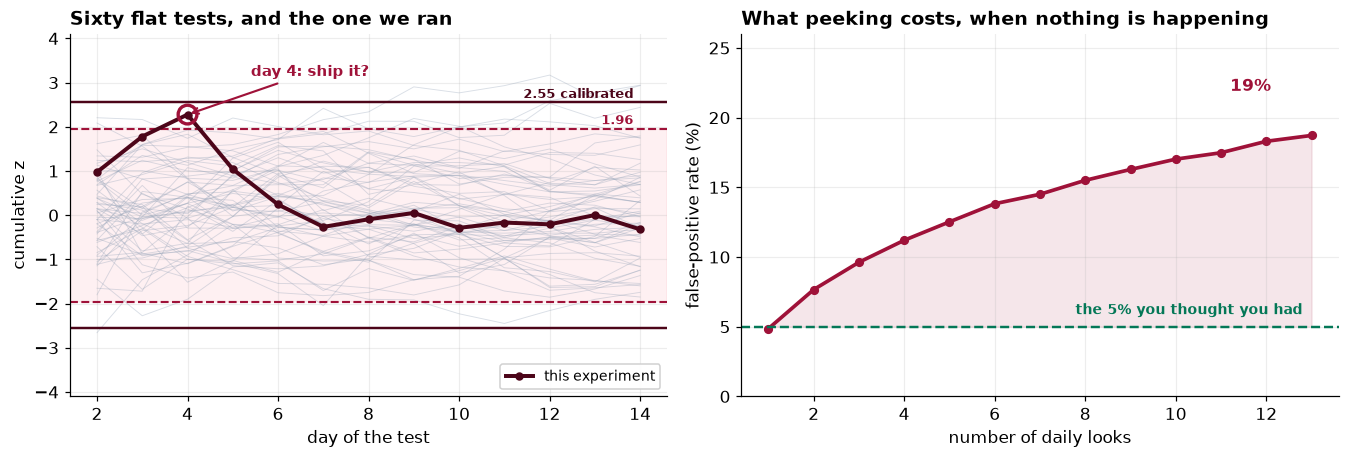

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

ax = axes[0]
days = np.arange(2, 15)
zs = []
for d in days:
    s = df[df.assign_day <= d]
    a = s[s.arm=="control"].converted.values; b = s[s.arm=="treatment"].converted.values
    zz, _ = proportions_ztest([b.sum(), a.sum()], [len(b), len(a)]); zs.append(zz)
for path in Z[:60, 1:]:
    ax.plot(days, path, color=MUT, lw=0.6, alpha=0.35)
ax.axhspan(-1.96, 1.96, color=LT, alpha=0.10)
ax.axhline(1.96, color=RS, lw=1.4, ls="--"); ax.axhline(-1.96, color=RS, lw=1.4, ls="--")
ax.axhline(c, color=DK, lw=1.6); ax.axhline(-c, color=DK, lw=1.6)
ax.plot(days, zs, color=DK, lw=2.6, marker="o", ms=4.5, zorder=5, label="this experiment")
ax.scatter([4], [zs[2]], s=150, facecolor="none", edgecolor=RS, lw=2.2, zorder=6)
ax.annotate("day 4: ship it?", xy=(4, zs[2]), xytext=(5.4, 3.15), color=RS, fontweight="bold",
            fontsize=9.5, arrowprops=dict(arrowstyle="->", color=RS, lw=1.4))
ax.text(13.85, 2.06, "1.96", ha="right", fontsize=8.5, color=RS, fontweight="bold")
ax.text(13.85, c+0.10, f"{c:.2f} calibrated", ha="right", fontsize=8.5, color=DK, fontweight="bold")
ax.set_xlabel("day of the test"); ax.set_ylabel("cumulative z")
ax.set_ylim(-4.1, 4.1); ax.set_title("Sixty flat tests, and the one we ran")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

ax = axes[1]
ks = np.arange(1, 14)
rates = [(np.abs(looks[:, :k]) > 1.96).any(axis=1).mean() for k in ks]
ax.plot(ks, np.array(rates)*100, color=RS, lw=2.4, marker="o", ms=5)
ax.axhline(5, color=GD, lw=1.6, ls="--")
ax.text(12.8, 5.9, "the 5% you thought you had", ha="right", color=GD, fontsize=9, fontweight="bold")
ax.fill_between(ks, 5, np.array(rates)*100, color=RS, alpha=0.10)
ax.annotate(f"{rates[-1]*100:.0f}%", xy=(13, rates[-1]*100), xytext=(11.2, rates[-1]*100+3.2),
            color=RS, fontweight="bold", fontsize=11)
ax.set_xlabel("number of daily looks"); ax.set_ylabel("false-positive rate (%)")
ax.set_ylim(0, 26); ax.set_title("What peeking costs, when nothing is happening")
plt.tight_layout(); plt.show()

**Left:** sixty simulated flat tests in gray, all of them wandering, several of them crossing the dashed 1.96 line at some point. Our experiment is the dark line, and the circled point is day 4. The solid lines are the calibrated boundary, which it does not reach. **Right:** the false-positive rate as a function of how many times you look, rising from 5 percent to almost 19.

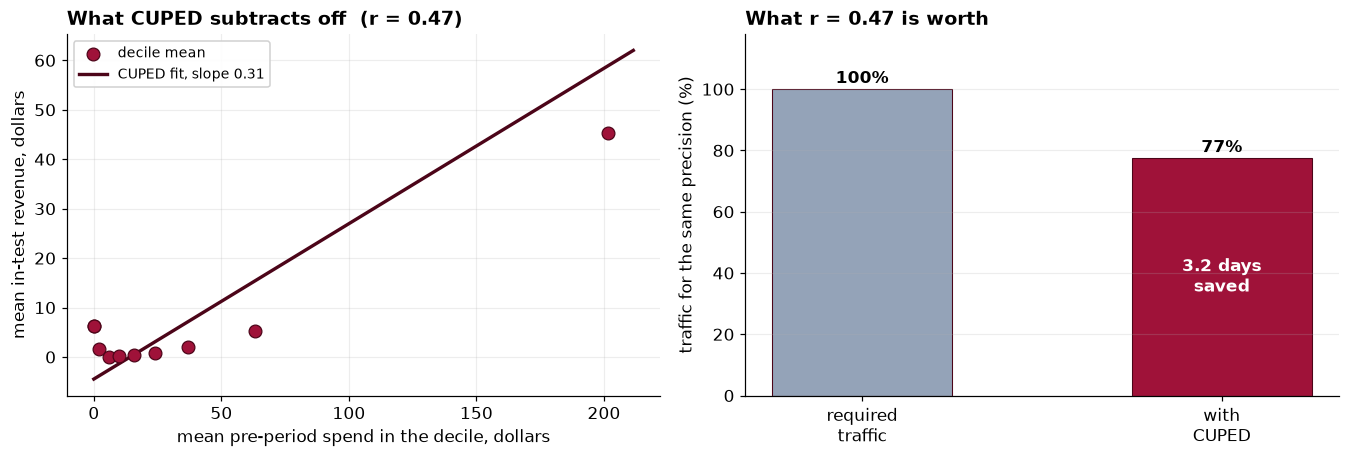

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

ax = axes[0]
# Bin visitors by pre-period spend and plot the mean in-test revenue per bin. CUPED's
# adjustment is linear in the covariate, so this is the relationship it actually removes.
q = pd.qcut(rev.pre_revenue_30d.rank(method="first"), 10, labels=False)
bins = rev.assign(_b=q).groupby("_b").agg(x=("pre_revenue_30d", "mean"),
                                          y=("revenue", "mean"), n=("revenue", "size"))
ax.scatter(bins.x, bins.y, s=70, color=RS, edgecolor=DK, lw=0.8, zorder=4, label="decile mean")
xs = np.linspace(0, bins.x.max()*1.05, 50)
ax.plot(xs, theta*(xs - X.mean()) + Y.mean(), color=DK, lw=2.2, zorder=3,
        label=f"CUPED fit, slope {theta:.2f}")
ax.set_xlabel("mean pre-period spend in the decile, dollars")
ax.set_ylabel("mean in-test revenue, dollars")
ax.set_title(f"What CUPED subtracts off  (r = {rho:.2f})")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

ax = axes[1]
bars = ["required\ntraffic", "with\nCUPED"]
vals = [100, ratio*100]
b = ax.bar(bars, vals, color=[MUT, RS], edgecolor=DK, lw=0.7, width=0.5)
for rect, v in zip(b, vals):
    ax.text(rect.get_x()+rect.get_width()/2, v+2, f"{v:.0f}%", ha="center", fontweight="bold")
ax.text(1, ratio*100/2, f"{14*(1-ratio):.1f} days\nsaved", ha="center", va="center",
        color="white", fontweight="bold", fontsize=11)
ax.set_ylim(0, 118); ax.set_ylabel("traffic for the same precision (%)")
ax.set_title("What r = 0.47 is worth"); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Left:** visitors grouped into deciles of prior spend, plotted against mean in-test revenue, with the linear adjustment CUPED applies. The relationship is real and close to linear across most of the range. The top decile sits below the line, which is worth noticing: the adjustment is least trustworthy exactly where the covariate is most extreme. **Right:** what that relationship buys. The same precision on 77.5 percent of the traffic.

## Step 11 &middot; Ethics, bias, and limits
- **A stopping rule chosen after seeing data is not a stopping rule.** Everything in this notebook depends on P7 having been written on day 0. "We will run it until it is significant" is not a plan, it is a guarantee of a false positive given enough patience.
- **Report the whole sequence, not the moment you stopped.** If the test was monitored, say so and say against what boundary. A p-value reported without its stopping rule is uninterpretable, because the same 0.023 means one thing at a planned analysis and something much weaker as the best of thirteen looks.
- **A null result is a result, and it should be published internally.** Teams that only write up wins build a library in which every idea worked, which is how organizations come to believe things that are not true.
- **The MDE is an ethical decision as much as a statistical one.** Setting it too low commits the company to tests that cannot finish; setting it too high means shipping changes whose real effect was never measurable. Either way the number belongs in the plan, with the reasoning next to it.
- **Secondary metrics cannot rescue a null primary.** There are two of them here and twenty in most real tests, and searching them after a flat headline is the multiple-comparisons problem of Capstone 4 wearing a different hat. Report them as estimates with intervals, which is what P11 requires.
- **Experiments are run on people.** Visitors were not asked whether they wanted a redesigned checkout. That is normally uncontroversial, and it stops being uncontroversial when the manipulation touches price, credit, safety or anything a person would object to if told. The threshold question is whether you would be comfortable describing the test to the people in it.

---
**From analysis to report.** The notebook carries the chain: the pre-registered plan, the sample size and what a smaller MDE would have cost, the four faults cleaned out of the log, the SRM check, the day-4 result that would have shipped, the simulation that prices peeking at 20 percent, the calibrated boundary that would have held, the CUPED saving, and the final interval that rules out the effect the business cared about. The written reports turn it into a recommendation a product lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.